RQ2: Can introducing semantically valid, artificially crafted, and maliciously altered network flow perturbations, creating the effects of a network evasion attack, into an IDS training dataset, such as the Unified Multimodal NIDS CIC-IDS2019 dataset, reduce the robustness of an existing pre-trained model? 

H20: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s testing dataset has no statistically significant effect on the model's overall performance.

H2a: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s testing dataset has a statistically significant effect on the model's overall performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
dos_set = df[df["label"].str.contains("DoS", case=False, na=False)]
dos_sample = (dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
dos_sample["label"] = "DoS_ATTACK"
dos_sample["label"].value_counts()
non_dos_set = df[(df["label"] != "BENIGN") & (~df["label"].str.contains("DoS", case=False, na=False))]
non_dos_sample = (non_dos_set.sample(n=50000, random_state=42, replace=False).reset_index(drop=True))
non_dos_sample["label"] = "NON_DoS_ATTACK"
attack_sample =pd.concat([dos_sample, non_dos_sample]).reset_index(drop=True)
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=attack_sample.shape[0], replace=True, random_state=42)
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [4]:
model = XGBClassifier(
    n_estimators=300,   
    max_depth=6,
    learning_rate=0.03,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


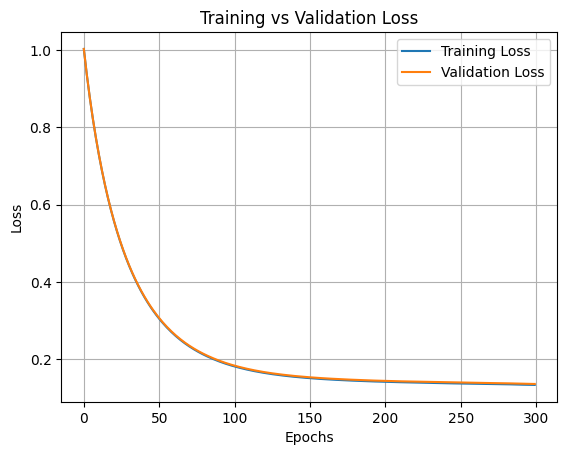

In [5]:
results = model.evals_result()

train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.931075
Weighted F1: 0.9309992764610663
Macro F1: 0.9080240334065622
ROC-AUC: 0.9916629795833334


In [7]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     20000
    DoS_ATTACK       0.89      0.83      0.86     10000
NON_DoS_ATTACK       0.84      0.89      0.87     10000

      accuracy                           0.93     40000
     macro avg       0.91      0.91      0.91     40000
  weighted avg       0.93      0.93      0.93     40000



In [8]:
EPSILONS = {
    "Control (clean)":    None,
    "Epsilon 0.01":       "adversarial_epsilon_0.01.csv",
    "Epsilon 0.05":       "adversarial_epsilon_0.05.csv",
    "Epsilon 0.1":       "adversarial_epsilon_0.1.csv",
#    "Epsilon 0.20":       "adversarial_epsilon_0.20.csv",
#    "Epsilon 0.30":       "adversarial_epsilon_0.30.csv",
#    "Epsilon 0.40":       "adversarial_epsilon_0.40.csv",
    "Epsilon 0.5":       "adversarial_epsilon_0.5.csv",
}

N_BOOTSTRAPS = 5000
all_results_rq2 = []
group_preds_rq2 = {}
for group_name, csv_path in EPSILONS.items():
    if csv_path is None:
        X_eval = X_test
        y_eval = y_test
    else:
        ae_df_rq2 = pd.read_csv(csv_path)
        X_eval = ae_df_rq2.drop(columns=["true_label", "y_pred"], errors="ignore").select_dtypes(include=[np.number])
        X_eval.replace([np.inf, -np.inf], np.nan, inplace=True)
        X_eval.fillna(0, inplace=True)
        X_eval = X_eval.astype("float32")
        y_eval = ae_df_rq2["true_label"].reset_index(drop=True).values.astype(int)
    y_pred = model.predict(X_eval)
    y_pred = np.array(y_pred)
    y_eval = np.array(y_eval)
    group_preds_rq2[group_name] = (y_eval, y_pred)
    acc  = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_eval, y_pred, average="macro", zero_division=0)
    mac  = f1_score(y_eval, y_pred, average="macro")
    wt   = f1_score(y_eval, y_pred, average="weighted")
    acc_b, prec_b, rec_b, mac_b, wt_b = [], [], [], [], []
    for _ in range(N_BOOTSTRAPS):
        idx = resample(np.arange(len(y_eval)), replace=False)
        acc_b.append(accuracy_score(y_eval[idx], y_pred[idx]))
        prec_b.append(precision_score(y_eval[idx], y_pred[idx], average="macro", zero_division=0))
        rec_b.append(recall_score(y_eval[idx], y_pred[idx], average="macro", zero_division=0))
        mac_b.append(f1_score(y_eval[idx], y_pred[idx], average="macro"))
        wt_b.append(f1_score(y_eval[idx], y_pred[idx], average="weighted"))
    def ci(vals): return np.percentile(vals, 2.5), np.percentile(vals, 97.5)
    all_results_rq2.append({
        "Group":           group_name,
        "Accuracy":        round(acc, 4),
        "Acc CI":          ci(acc_b),
        "Macro Precision": round(prec, 4),
        "Prec CI":         ci(prec_b),
        "Macro Recall":    round(rec, 4),
        "Rec CI":          ci(rec_b),
        "Macro F1":        round(mac, 4),
        "MacF1 CI":        ci(mac_b),
        "Weighted F1":     round(wt, 4),
        "WtF1 CI":         ci(wt_b),
    })
summary_rq2 = pd.DataFrame([{
    "Group":           r["Group"],
    "Accuracy":        f"{r['Accuracy']} [{r['Acc CI'][0]:.4f}, {r['Acc CI'][1]:.4f}]",
    "Macro Precision": f"{r['Macro Precision']} [{r['Prec CI'][0]:.4f}, {r['Prec CI'][1]:.4f}]",
    "Macro Recall":    f"{r['Macro Recall']} [{r['Rec CI'][0]:.4f}, {r['Rec CI'][1]:.4f}]",
    "Macro F1":        f"{r['Macro F1']} [{r['MacF1 CI'][0]:.4f}, {r['MacF1 CI'][1]:.4f}]",
    "Weighted F1":     f"{r['Weighted F1']} [{r['WtF1 CI'][0]:.4f}, {r['WtF1 CI'][1]:.4f}]",
} for r in all_results_rq2])
print("\n\n══ RQ2 SUMMARY WITH 95% BOOTSTRAP CIs ══")
display(summary_rq2)
print("\n══ BOOTSTRAP p-VALUES vs CONTROL ══")
ctrl_y, ctrl_pred_rq2 = group_preds_rq2["Control (clean)"]
hyp_results_rq2 = []
for group_name, (y_eval, exp_pred) in group_preds_rq2.items():
    if group_name == "Control (clean)":
        continue
    diffs = []
    for _ in range(N_BOOTSTRAPS):
        idx_c = resample(np.arange(len(ctrl_y)), replace=False)
        idx_e = resample(np.arange(len(y_eval)), replace=False)
        diffs.append(f1_score(ctrl_y[idx_c], ctrl_pred_rq2[idx_c], average="macro") - f1_score(y_eval[idx_e], exp_pred[idx_e], average="macro"))
    diffs = np.array(diffs)
    p = min(np.mean(diffs <= 0), np.mean(diffs >= 0)) * 2
    hyp_results_rq2.append({
        "Comparison":   f"Control vs {group_name}",
        "Mean F1 Drop": round(np.mean(diffs), 4),
        "95% CI":       f"[{np.percentile(diffs, 2.5):.4f}, {np.percentile(diffs, 97.5):.4f}]",
        "p-value":      round(p, 6),
        "Significant":  "Yes" if p < 0.05 else "No",
    })
display(pd.DataFrame(hyp_results_rq2))



══ RQ2 SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Control (clean),"0.9311 [0.9311, 0.9311]","0.9091 [0.9091, 0.9091]","0.9081 [0.9081, 0.9081]","0.908 [0.9080, 0.9080]","0.931 [0.9310, 0.9310]"
1,Epsilon 0.01,"0.6103 [0.6103, 0.6103]","0.7433 [0.7433, 0.7433]","0.6103 [0.6103, 0.6103]","0.6124 [0.6124, 0.6124]","0.6124 [0.6124, 0.6124]"
2,Epsilon 0.05,"0.7292 [0.7292, 0.7292]","0.7983 [0.7983, 0.7983]","0.7292 [0.7292, 0.7292]","0.7224 [0.7224, 0.7224]","0.7224 [0.7224, 0.7224]"
3,Epsilon 0.1,"0.727 [0.7270, 0.7270]","0.7937 [0.7937, 0.7937]","0.727 [0.7270, 0.7270]","0.7208 [0.7208, 0.7208]","0.7208 [0.7208, 0.7208]"
4,Epsilon 0.5,"0.7373 [0.7373, 0.7373]","0.7989 [0.7989, 0.7989]","0.7373 [0.7373, 0.7373]","0.7306 [0.7306, 0.7306]","0.7306 [0.7306, 0.7306]"



══ BOOTSTRAP p-VALUES vs CONTROL ══


,Comparison,Mean F1 Drop,95% CI,p-value,Significant
0,Control vs Epsilon 0.01,0.2956,"[0.2956, 0.2956]",0.0,Yes
1,Control vs Epsilon 0.05,0.1857,"[0.1857, 0.1857]",0.0,Yes
2,Control vs Epsilon 0.1,0.1872,"[0.1872, 0.1872]",0.0,Yes
3,Control vs Epsilon 0.5,0.1774,"[0.1774, 0.1774]",0.0,Yes
